## Architecture Design and Intuition

The proposed model, referred to as **CNN_Scratch**, is a deep Convolutional Neural Network implemented entirely from scratch, without relying on high-level deep learning primitives for convolution, batch normalization, pooling, or linear layers.

---

## Overall Architecture

The network accepts an input image with **9 input channels** and produces predictions across **16 output classes**. The architecture consists of **six convolutional feature extraction blocks**, followed by an adaptive pooling layer and fully connected classification layers.

Each convolutional block follows a consistent design pattern:

- Convolution layer  
- Batch normalization  
- ReLU activation  
- Max pooling  

---

## Convolutional Feature Extraction Blocks

### Block 1
- Convolution: 9 → 16 channels, kernel size 3×3, padding 1 
- Batch Normalization  
- ReLU Activation  
- Max Pooling (2×2)  

### Block 2
- Convolution: 16 → 32 channels  
- Batch Normalization  
- ReLU Activation  
- Max Pooling (2×2)  

### Block 3
- Convolution: 32 → 64 channels  
- Batch Normalization  
- ReLU Activation  
- Max Pooling (2×2)  

### Block 4
- Convolution: 64 → 96 channels  
- Batch Normalization  
- ReLU Activation  
- Max Pooling (2×2)  

### Block 5
- Convolution: 96 → 128 channels  
- Batch Normalization  
- ReLU Activation  
- Max Pooling (2×2)  

### Block 6
- Convolution: 128 → 192 channels  
- Batch Normalization  
- ReLU Activation  
- Max Pooling (2×2)  

---

## Adaptive Feature Aggregation

After the convolutional blocks, an **Adaptive Average Pooling** layer is applied to reduce the spatial dimensions of the feature maps to **1×1**, regardless of the original input size.

The resulting feature tensor has a shape of **192 × 1 × 1**.

---

## Fully Connected Classification Head

The pooled feature vector is flattened and passed through two fully connected layers:

### Fully Connected Layer 1
- Input features: 192  
- Output features: 128  
- ReLU activation  
- Dropout with probability 0.5 for regularization  

### Fully Connected Layer 2 (Output Layer)
- Input features: 128  
- Output features: 16 (number of classes)  

The final layer produces class logits for multi-class classification.

---

## Experimentation History

Before finalizing the **6-block sequential architecture**, extensive internal experimentation was conducted to identify the most effective strategy for fusing multi-input image data.

### Late Fusion Approaches ( Siamese NN )
- Initial experiments explored *late fusion* architectures, where each of the three input images was processed independently using separate network branches.  
- Feature representations from these branches were merged only at the final classification layer.  
- This approach consistently resulted in lower F1-scores, likely because the model was unable to learn meaningful correlations between low-level features across different inputs.  

### Mid-Fusion Architectures
- Subsequent experiments investigated *mid-fusion* strategies, where features were merged at intermediate layers within the network.  
- While this improved performance compared to late fusion, the results were still inferior to early fusion methods.  
- The partial separation of feature extraction limited the model’s ability to fully exploit cross-input dependencies.  

### Residual (ResNet-style) Connections
- Residual skip connections were incorporated to improve gradient flow and training stability.  
- However, given the from-scratch training setup and dataset characteristics, these architectures showed less stable convergence.  
- A simpler 6-block sequential design without skip connections achieved higher validation performance and more consistent training behavior.  

### Final Architecture Selection
- The final model adopts an early-fusion strategy by stacking the three RGB images into a single 9-channel input.  
- This sequential architecture outperformed all alternatives by enabling shared feature learning from the earliest convolutional layers.  
- As a result, it demonstrated superior validation metrics and overall robustness.  

---

## Data Preprocessing Pipeline

The data preprocessing pipeline is designed to convert raw music-related image data into a structured format compatible with the model’s custom **9-channel input representation**. Each step is carefully constructed to preserve spatial alignment across inputs while ensuring numerical stability during training.

### Dataset Handling
- A custom dataset class, `MultiInputImageDataset`, is used to load image triplets (`input_1`, `input_2`, `input_3`) as specified in the metadata.  
- Each sample consists of three semantically related RGB images that jointly represent a single data instance.  

### Synchronized Data Augmentation
- To maintain spatial consistency across the image triplet, data augmentation is applied in a synchronized manner.  
- Random transformations such as `RandomHorizontalFlip` and `RandomRotation` are executed using a shared random seed.  
- This guarantees that all three images within a sample undergo identical geometric transformations before being combined.  

### Normalization
Each image is normalized using standard ImageNet statistics:

- **Mean:** `[0.485, 0.456, 0.406]`  
- **Standard Deviation:** `[0.229, 0.224, 0.225]`  

Normalization helps stabilize training and improves convergence behavior.

### Channel-wise Concatenation
- After preprocessing, the three RGB images are stacked along the channel dimension.  
- This results in a single tensor of shape **(9, 369, 496)**, which serves as the final input to the model.  

---

## Training Details

This section describes the training configuration used to optimize the proposed CNN_Scratch model.

### Optimizer
The model is trained using the **Adam optimizer**.  
A small **weight decay (L2 regularization)** term is applied to reduce overfitting by discouraging overly large weights.

- Optimizer: Adam  
- Weight decay: 1 × 10⁻⁴  

---

## Learning Rate Scheduling

We experimented with multiple learning rate scheduling strategies to improve convergence.  
Specifically, we used **ReduceLROnPlateau** in two configurations:  
(i) with a patience of 3.  
(ii) with a patience of 5 and a threshold of 1e-3.  

We also evaluated an **Exponential Learning Rate Scheduler** with a decay factor (gamma = 0.97).  

We also tried using **Cosine Annealing Learning Rate Scheduling** with Tmax = 80, which yielded smoother learning rate decay and more stable training.



---

### Loss Function
The model is trained using **Categorical Cross-Entropy Loss** with **label smoothing**.

Label smoothing helps prevent the model from becoming overconfident by softening the target labels, which often leads to better generalization and improved F1-score in multi-class classification tasks.

- Loss function: Cross-Entropy Loss  
- Label smoothing factor: 0.1  

---

### Batch Size
A batch size of **32** is used for both training and validation.

---

### Number of Epochs
The model is trained for a maximum of **80 epochs**.

---

## Evaluation Strategy and Metrics

### Validation Split
A subset of the training data, consisting of approximately **1,825 samples**, was reserved for validation. This split was used to continuously monitor model performance during training and to guide model selection and tuning decisions.

### Primary Metric
The **Macro F1-score** was chosen as the primary evaluation metric to ensure balanced performance across all **16 music categories**, treating each class equally regardless of class frequency or imbalance.

### Secondary Analysis
A Confusion Matrix and Classification Report were used to identify classes where the model experienced difficulty, allowing for targeted tuning and refinement.

---

## Contributions of Each Team Member

All team members contributed equally to the successful completion of this project. Responsibilities were shared collaboratively across all stages of development, including data preprocessing, model design, experimentation, training, evaluation, and documentation.


# Importing Necessary Libraries

In [1]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as transforms
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import torch.nn.functional as F
import math


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


# Data Preprocessing

In [3]:
BASE_PATH = "/kaggle/input/cs-776-competition-2025-2026-sem-2"

TRAIN_CSV = f"{BASE_PATH}/dataset_music/train/metadata.csv"


In [4]:
class MultiInputImageDataset(Dataset):
    def __init__(self, root_dir, csv_file, train=True, transform=None):
        self.root_dir = root_dir
        self.data = pd.read_csv(csv_file)
        self.train = train
        self.transform = transform
        self.to_tensor = transforms.ToTensor()

    def __len__(self):
        return len(self.data)

    def load_image(self, image_path):
        image_path = image_path.lstrip("./")
        full_path = os.path.join(self.root_dir, image_path)
        return Image.open(full_path).convert("RGB")

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        
        # 1. Load images
        img1 = self.load_image(row["input_1"] if "input_1" in row else row["input_1_path"])
        img2 = self.load_image(row["input_2"])
        img3 = self.load_image(row["input_3"])

        # 2. Apply Transforms
        if self.transform is not None:
            if self.train:
                seed = np.random.randint(2147483647)
                def apply_sync(img):
                    random.seed(seed)
                    torch.manual_seed(seed)
                    return self.transform(img)

                img1 = apply_sync(img1)
                img2 = apply_sync(img2)
                img3 = apply_sync(img3)
            else:
                # TEST: Apply val_transform (Normalization + Resize)
                img1 = self.transform(img1)
                img2 = self.transform(img2)
                img3 = self.transform(img3)
        else:
            # Fallback if no transform is provided at all
            img1 = self.to_tensor(img1)
            img2 = self.to_tensor(img2)
            img3 = self.to_tensor(img3)

        # 3. Stack into 9 channels
        image = torch.cat([img1, img2, img3], dim=0)

        if self.train:
            label = torch.tensor(row["target"], dtype=torch.long)
            return image, label
        else:
            return image, row["id"]

# Data Augmentation

In [5]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Train-Test-Split

In [6]:
train_full = MultiInputImageDataset(
    root_dir=BASE_PATH,
    csv_file=TRAIN_CSV,
    train=True,
    transform=train_transform
)


val_full = MultiInputImageDataset(
    root_dir=BASE_PATH,
    csv_file=TRAIN_CSV,
    train=True, 
    transform=val_transform
)


In [7]:
np.random.seed(42)
indices = np.random.permutation(len(train_full))
train_indices = indices[:20000]
val_indices = indices[20000:]

# 4. Use Subsets on the correct versions
train_dataset = Subset(train_full, train_indices)
val_dataset = Subset(val_full, val_indices)

# DataLoader

In [8]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=(device.type == "cuda")
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=(device.type == "cuda")
)



In [9]:
print(train_loader)
print(val_loader)


# Implementing layers from scratch

## 1) Convolution Layer

In [10]:
class Conv2D_Scratch(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        super().__init__()

        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

        # Learnable weights and bias
        self.weight = nn.Parameter(
            torch.randn(out_channels, in_channels, kernel_size, kernel_size) * math.sqrt(2. / (in_channels * kernel_size * kernel_size))
        )
        self.bias = nn.Parameter(torch.zeros(out_channels))

    def forward(self, x):
        B, C, H, W = x.shape

        # Unfold input (B, C*k*k, L)
        x_unf = F.unfold(
            x,
            kernel_size=self.kernel_size,
            stride=self.stride,
            padding=self.padding
        )

        # Reshape weights (out_channels, C*k*k)
        w = self.weight.view(self.weight.size(0), -1)

        # Convolution via matrix multiplication
        out = w @ x_unf        
        out = out + self.bias.view(1, -1, 1)

        # Output spatial size
        H_out = (H + 2*self.padding - self.kernel_size)//self.stride + 1
        W_out = (W + 2*self.padding - self.kernel_size)//self.stride + 1

        return out.view(B, -1, H_out, W_out)


## 2) Max Pooling

In [11]:
class MaxPool2D_Scratch(nn.Module):
    def __init__(self, kernel_size, stride):
        super().__init__()
        self.kernel_size = kernel_size
        self.stride = stride

    def forward(self, x):
        B, C, H, W = x.shape

        x_unf = F.unfold(
            x,
            kernel_size=self.kernel_size,
            stride=self.stride
        )

        x_unf = x_unf.view(B, C, self.kernel_size*self.kernel_size, -1)
        out, _ = x_unf.max(dim=2)

        H_out = (H - self.kernel_size)//self.stride + 1
        W_out = (W - self.kernel_size)//self.stride + 1

        return out.view(B, C, H_out, W_out)


## 3) Activation Functions

In [12]:
class ReLU_Scratch(nn.Module):
    def forward(self, x):
        return torch.clamp(x, min=0.0)


## 4) Batch Normalization

In [13]:
class BatchNorm2D_Scratch(nn.Module):
    def __init__(self, num_features, eps=1e-5, momentum=0.1):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(num_features))
        self.beta = nn.Parameter(torch.zeros(num_features))

        self.register_buffer("running_mean", torch.zeros(num_features))
        self.register_buffer("running_var", torch.ones(num_features))

        self.eps = eps
        self.momentum = momentum

    def forward(self, x):
        if self.training:
            mean = x.mean(dim=(0, 2, 3))
            var = x.var(dim=(0, 2, 3), unbiased=False)

            self.running_mean = (1 - self.momentum)*self.running_mean + self.momentum*mean
            self.running_var = (1 - self.momentum)*self.running_var + self.momentum*var
        else:
            mean = self.running_mean
            var = self.running_var

        x_hat = (x - mean.view(1, -1, 1, 1)) / torch.sqrt(var.view(1, -1, 1, 1) + self.eps)
        return self.gamma.view(1, -1, 1, 1)*x_hat + self.beta.view(1, -1, 1, 1)


## 5) Linear Layer

In [15]:
class Linear_Scratch(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * math.sqrt(2. / in_features))
        self.bias = nn.Parameter(torch.zeros(out_features))

    def forward(self, x):
        return x @ self.weight.t() + self.bias


## 6) Global Adaptive Pooling

In [16]:
class AdaptiveAvgPool2D_Scratch(nn.Module):
    def __init__(self, output_size):
        super().__init__()
        self.out_h, self.out_w = output_size

    def forward(self, x):
        B, C, H, W = x.shape
        stride_h = H // self.out_h
        stride_w = W // self.out_w

        kernel_h = H - (self.out_h - 1) * stride_h
        kernel_w = W - (self.out_w - 1) * stride_w

        patches = torch.nn.functional.unfold(
            x,
            kernel_size=(kernel_h, kernel_w),
            stride=(stride_h, stride_w)
        )

        patches = patches.view(
            B, C, kernel_h * kernel_w, self.out_h * self.out_w
        )

        out = patches.mean(dim=2)
        return out.view(B, C, self.out_h, self.out_w)


# Model Architecture

In [17]:
class CNN_Scratch(nn.Module):
    def __init__(self, num_classes=16):
        super().__init__()

        # -------- Block 1 --------
        self.conv1 = Conv2D_Scratch(9, 16, kernel_size=3, padding=1)
        self.bn1   = BatchNorm2D_Scratch(16)
        self.pool1 = MaxPool2D_Scratch(2, 2)

        # -------- Block 2 --------
        self.conv2 = Conv2D_Scratch(16, 32, kernel_size=3, padding=1)
        self.bn2   = BatchNorm2D_Scratch(32)
        self.pool2 = MaxPool2D_Scratch(2, 2)

        # -------- Block 3 --------
        self.conv3 = Conv2D_Scratch(32, 64, kernel_size=3, padding=1)
        self.bn3   = BatchNorm2D_Scratch(64)
        self.pool3 = MaxPool2D_Scratch(2, 2)

        # -------- Block 4 --------
        self.conv4 = Conv2D_Scratch(64, 96, kernel_size=3, padding=1)
        self.bn4   = BatchNorm2D_Scratch(96)
        self.pool4 = MaxPool2D_Scratch(2, 2)

        # -------- Block 5 --------
        self.conv5 = Conv2D_Scratch(96, 128, kernel_size=3, padding=1)
        self.bn5   = BatchNorm2D_Scratch(128)
        self.pool5 = MaxPool2D_Scratch(2, 2)

        # -------- Block 6 --------
        self.conv6 = Conv2D_Scratch(128, 192, kernel_size=3, padding=1)
        self.bn6   = BatchNorm2D_Scratch(192)
        self.pool6 = MaxPool2D_Scratch(2, 2)

        # -------- Activation --------
        self.relu = ReLU_Scratch()

        # -------- Adaptive Pool (allowed, no params) --------
        self.adaptive_pool = AdaptiveAvgPool2D_Scratch((1, 1))

        # -------- Fully Connected (scratch) --------
        self.fc1 = Linear_Scratch(192 * 1 * 1, 128)
        self.fc2 = Linear_Scratch(128, num_classes)

        # -------- Dropout --------
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        x = self.pool1(self.relu(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu(self.bn3(self.conv3(x))))
        x = self.pool4(self.relu(self.bn4(self.conv4(x))))
        x = self.pool5(self.relu(self.bn5(self.conv5(x))))
        x = self.pool6(self.relu(self.bn6(self.conv6(x))))

        x = self.adaptive_pool(x)

        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)

        return self.fc2(x)


In [18]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = (device.type == "cuda")
scaler = torch.amp.GradScaler(enabled=use_amp)


In [19]:
train_losses, val_losses, val_f1s = [], [], []

# Initialize model

In [20]:

model = CNN_Scratch(num_classes=16).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',       
    factor=0.5,
    patience=5,        
    threshold=1e-3,    
    min_lr=5e-7      
)

# Training Model

In [21]:
def train_and_validate(model, train_loader, val_loader, criterion, optimizer, epochs):
    best_f1 = max(val_f1s) if len(val_f1s) > 0 else 0.0
    for epoch in range(epochs):
        # TRAIN
        model.train()
        train_loss = 0.0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            with torch.amp.autocast(device_type="cuda", enabled=use_amp):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        # VALIDATE
        model.eval()
        val_loss = 0.0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                with torch.amp.autocast(device_type="cuda", enabled=use_amp):
                    outputs = model(images)
        
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        f1 = f1_score(all_labels, all_preds, average="macro")
        val_f1s.append(f1)
        if f1 > best_f1:
            best_f1 = f1
            checkpoint = {
                'model_state': model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'train_losses': train_losses,  
                'val_losses': val_losses,      
                'val_f1s': val_f1s,           
                'best_f1': best_f1
            }
            torch.save(checkpoint, "best_model.pth")
            print(f"Best model saved with F1: {f1:.4f}")
        scheduler.step(f1)
        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val F1: {f1:.4f}"
        )

    return train_losses, val_losses, val_f1s


In [24]:
train_losses, val_losses, val_f1s = train_and_validate(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=80
)


Best model saved with F1: 0.3930
Epoch 1/80 | Train Loss: 2.1505 | Val Loss: 1.8856 | Val F1: 0.3930
Best model saved with F1: 0.4995
Epoch 2/80 | Train Loss: 1.8223 | Val Loss: 1.6941 | Val F1: 0.4995
Best model saved with F1: 0.5770
Epoch 3/80 | Train Loss: 1.6982 | Val Loss: 1.5497 | Val F1: 0.5770
Epoch 4/80 | Train Loss: 1.6164 | Val Loss: 1.5598 | Val F1: 0.5601
Best model saved with F1: 0.5813
Epoch 5/80 | Train Loss: 1.5643 | Val Loss: 1.4621 | Val F1: 0.5813
Best model saved with F1: 0.6374
Epoch 6/80 | Train Loss: 1.5094 | Val Loss: 1.4226 | Val F1: 0.6374
Epoch 7/80 | Train Loss: 1.4693 | Val Loss: 1.3906 | Val F1: 0.6231
Best model saved with F1: 0.6817
Epoch 8/80 | Train Loss: 1.4362 | Val Loss: 1.3487 | Val F1: 0.6817
Epoch 9/80 | Train Loss: 1.3935 | Val Loss: 1.3347 | Val F1: 0.6536
Epoch 10/80 | Train Loss: 1.3684 | Val Loss: 1.3752 | Val F1: 0.6510
Epoch 11/80 | Train Loss: 1.3365 | Val Loss: 1.3556 | Val F1: 0.6695
Best model saved with F1: 0.7265
Epoch 12/80 | Train

# Load model from any checkpoint

In [22]:
def load_checkpoint(model, optimizer, path):
    if os.path.exists(path):
        ckpt = torch.load(path, map_location=device)
        model.load_state_dict(ckpt["model_state"])
        optimizer.load_state_dict(ckpt["optimizer_state"])
        
        t_losses = ckpt.get("train_losses", [])
        v_losses = ckpt.get("val_losses", [])
        v_f1s = ckpt.get("val_f1s", [])
        
        best_f1 = ckpt.get("best_f1", 0.0)
        start_epoch = len(t_losses)
        
        print(f"Resuming from epoch {start_epoch} | Best F1: {best_f1:.4f}")
        return start_epoch, best_f1, t_losses, v_losses, v_f1s
    
    print("No checkpoint found. Starting from scratch.")
    return 0, 0.0, [], [], []


In [23]:
print(optimizer.param_groups[0]["lr"])

0.0005


# Current Model Saved 

In [24]:
checkpoint = {
                'model_state': model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'train_losses': train_losses, 
                'val_losses': val_losses,    
                'val_f1s': val_f1s,    
                'best_f1': max(val_f1s) if len(val_f1s) > 0 else 0.0
}
save_path = "checkpoint_final.pth"
torch.save(checkpoint, save_path)
print(f"Model saved successfully to {save_path}")

Model saved successfully to checkpoint_final.pth


# Model Parameters

In [25]:

sample, _ = train_dataset[0]
C, H, W = sample.shape

print(f"Detected input shape: C={C}, H={H}, W={W}")

from torchinfo import summary

summary(
    model,
    input_size=(1, C, H, W),  
    col_names=[
        "input_size",
        "output_size",
        "num_params",
        "kernel_size",
        "mult_adds"
    ],
    depth=4
)


Detected input shape: C=9, H=369, W=496


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape              Mult-Adds
CNN_Scratch                              [1, 9, 369, 496]          [1, 16]                   --                        --                        --
├─Conv2D_Scratch: 1-1                    [1, 9, 369, 496]          [1, 16, 369, 496]         1,312                     3                         240,127,488
├─BatchNorm2D_Scratch: 1-2               [1, 16, 369, 496]         [1, 16, 369, 496]         32                        --                        --
├─ReLU_Scratch: 1-3                      [1, 16, 369, 496]         [1, 16, 369, 496]         --                        --                        --
├─MaxPool2D_Scratch: 1-4                 [1, 16, 369, 496]         [1, 16, 184, 248]         --                        2                         --
├─Conv2D_Scratch: 1-5                    [1, 16, 184, 248]         [1, 32, 184, 248]         4,6

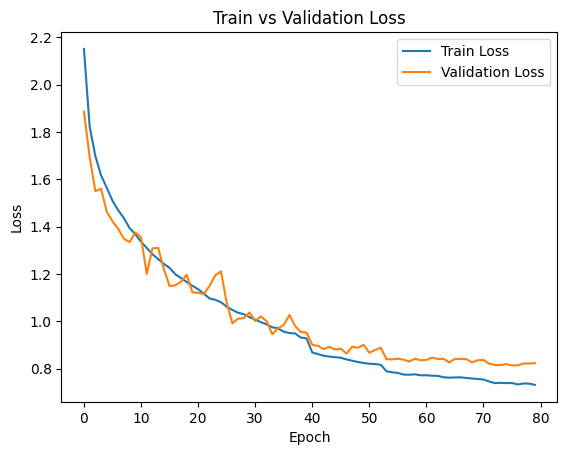

In [27]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.show()


In [26]:
TEST_CSV = f"{BASE_PATH}/dataset_music/test/metadata.csv"

test_dataset = MultiInputImageDataset(
    root_dir=BASE_PATH,
    csv_file=TEST_CSV,
    train=False,      
    transform=val_transform
)


In [27]:
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,     
    num_workers=4,
    pin_memory=True
)


# Best Model Load

In [30]:
path = "best_model.pth"
start_epoch, best_f1, train_losses, val_losses, val_f1s = load_checkpoint(model, optimizer, path)
print(best_f1)

Resuming from epoch 76 | Best F1: 0.9246
0.924607853315079


# Show Evaluatation Metrics 

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support

def evaluate_model(model, val_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 1. Calculate Metrics
    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro',zero_division=0)
    
    print(f"\n--- Validation Results ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("-" * 25)

    # 2. Detailed Report (Per-class Precision/Recall)
    print("\nDetailed Classification Report:")
    print(classification_report(all_labels, all_preds, zero_division=0))

    # 3. Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix: Val Dataset')
    plt.show()

    return f1


--- Validation Results ---
Accuracy:  0.9293
Precision: 0.9247
Recall:    0.9254
F1 Score:  0.9246
-------------------------

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       173
           1       0.97      0.96      0.97        72
           2       0.94      0.99      0.96       137
           3       0.99      0.96      0.98       187
           4       0.98      1.00      0.99        95
           5       0.79      0.88      0.83        93
           6       0.92      0.88      0.90        95
           7       0.94      0.92      0.93       111
           8       0.95      0.93      0.94       132
           9       0.90      0.90      0.90        84
          10       0.86      0.85      0.86        95
          11       0.91      0.90      0.91       201
          12       0.92      0.87      0.90       108
          13       0.87      0.93      0.90        71
          14       0.91      0

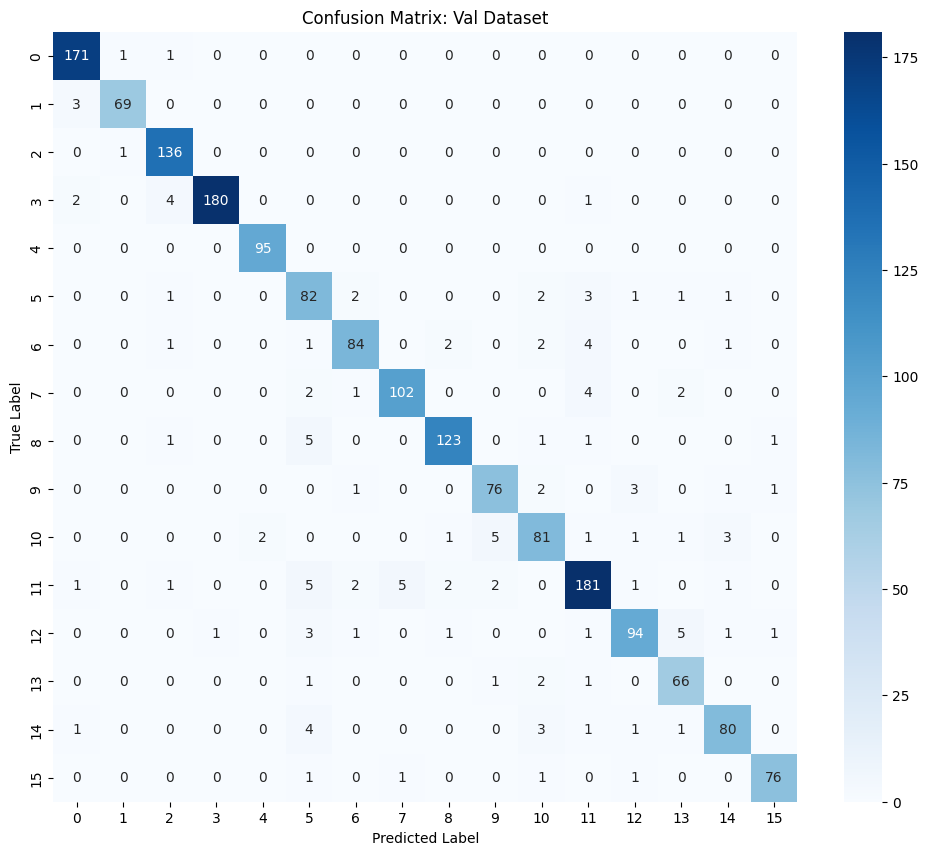

0.924607853315079

In [32]:
evaluate_model(model, val_loader, device)

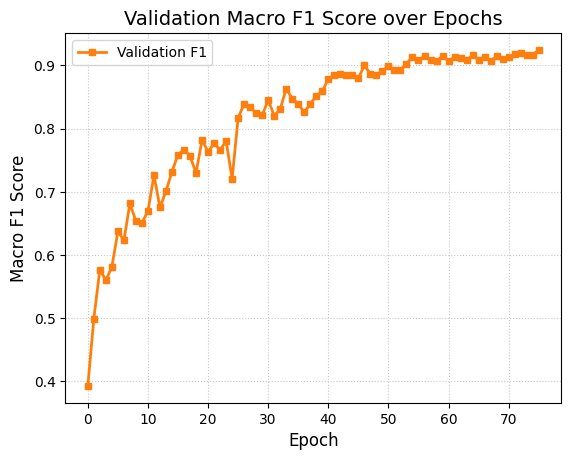

In [31]:
import matplotlib.pyplot as plt

def plot_validation_f1(val_f1s):
    # Plotting the validation F1 scores
    plt.plot(val_f1s, label='Validation F1', color='#ff7f0e', linewidth=2, marker='s', markersize=5)
    # Labels and Title
    plt.title('Validation Macro F1 Score over Epochs', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Macro F1 Score', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.savefig('val_f1_plot.png')
    plt.show()

# Usage:
plot_validation_f1(val_f1s)

# Inference

In [33]:
model.eval()
predictions = []

with torch.no_grad():
    for images, ids in test_loader:
        images = images.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
   
        for sample_id, pred in zip(ids, preds):
            predictions.append({
                "id": int(sample_id.cpu().item()),
                "target": int(pred.cpu().item())
            })


# Preparing CSV file for submission

In [34]:
submission_df = pd.DataFrame(predictions)
submission_df.to_csv("submission.csv", index=False)

print("Submission file saved as submission.csv")


Submission file saved as submission.csv
